# Классификация: SI больше 8

В данном ноутбуке решается задача бинарной классификации.

Цель - предсказать, превышает ли значение SI порог 8.

Показатель SI характеризует соотношение цитотоксичности и противовирусной активности соединения. Чем выше SI, тем более перспективным может быть соединение с точки зрения баланса эффективности и безопасности.

В отличие от задач классификации относительно медианы, здесь используется фиксированный порог 8. Поэтому классы могут быть несбалансированными, и при оценке качества особенно важно учитывать precision, recall и F1.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay

from sklearn.inspection import permutation_importance

# Загрузка данных

Загружаем исходный датасет и удаляем технические столбцы.

In [2]:
df = pd.read_excel("../data/compounds.xlsx")

df = df.drop(
    columns=[col for col in df.columns if "Unnamed" in col],
    errors="ignore"
)

df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


# Создание целевой переменной

Для классификации используется бинарный признак: превышает ли SI значение 8.

Класс 1 соответствует соединениям с SI > 8. Такие соединения можно рассматривать как более перспективные относительно выбранного порога.

Класс 0 соответствует соединениям с SI <= 8.

In [3]:
target = "SI"

threshold = 8

y = (df[target] > threshold).astype(int)

y.value_counts()

SI
0    644
1    357
Name: count, dtype: int64

In [4]:
y.value_counts(normalize=True)

SI
0    0.643357
1    0.356643
Name: proportion, dtype: float64

Распределение классов показывает умеренный дисбаланс: соединений с SI <= 8 больше, чем соединений с SI > 8.

Класс SI > 8 составляет около 36% выборки. Это не экстремальный дисбаланс, но accuracy уже не должна рассматриваться как единственная метрика качества.

Если модель будет часто предсказывать только класс SI <= 8, она сможет получить сравнительно неплохую accuracy, но не будет решать основную задачу поиска соединений с высоким SI.

Поэтому при оценке моделей основной акцент будет сделан на F1, recall, precision и ROC-AUC. Также при разделении данных используется stratify, чтобы сохранить соотношение классов в обучающей и тестовой выборках.

# Подготовка признаков

SI является расчетной величиной, связанной с IC50 и CC50.

Поэтому из признакового пространства исключаются IC50, CC50 и SI. Это нужно, чтобы избежать утечки данных и не дать модели напрямую восстановить целевой признак через связанные показатели.

В качестве признаков используются только числовые характеристики химических соединений.

In [5]:
X = df.drop(
    columns=["IC50, mM", "CC50, mM", "SI"],
    errors="ignore"
)

X = X.select_dtypes(include=["number"])

X.shape

(1001, 210)

# Разделение данных

Данные разделяются на обучающую и тестовую выборки.

Используется stratify, чтобы сохранить соотношение классов в train и test.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Метрики качества

Для оценки моделей используются accuracy, precision, recall, F1 и ROC-AUC.

В данной задаче особенно важны precision, recall и F1, так как классы могут быть несбалансированными.

In [7]:
def classification_metrics(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(y_true, y_proba)
    }

# Baseline модель

В качестве baseline используется DummyClassifier, который предсказывает наиболее частый класс.

Это позволяет понять, насколько модели машинного обучения превосходят простую стратегию без использования признаков.

In [8]:
dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

y_pred_dummy = dummy.predict(X_test)

baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_dummy),
    "precision": precision_score(
        y_test,
        y_pred_dummy,
        zero_division=0
    ),
    "recall": recall_score(
        y_test,
        y_pred_dummy,
        zero_division=0
    ),
    "f1": f1_score(
        y_test,
        y_pred_dummy,
        zero_division=0
    ),
    "roc_auc": 0.5,
    "model": "DummyClassifier"
}

baseline_metrics

{'accuracy': 0.6417910447761194,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': 0.5,
 'model': 'DummyClassifier'}

Baseline-модель DummyClassifier предсказывает наиболее частый класс, то есть SI <= 8.

Из-за умеренного дисбаланса классов такой подход дает accuracy около 0.64. Однако precision, recall и F1 равны 0, так как модель не выделяет ни одного объекта класса SI > 8.

Это показывает, что accuracy в данной задаче нельзя использовать как единственную метрику качества. Модель может иметь сравнительно неплохую accuracy, но при этом полностью игнорировать потенциально перспективные соединения.

Поэтому при дальнейшем сравнении моделей основной акцент будет сделан на F1, recall, precision и ROC-AUC.

# Сравнение моделей

Для решения задачи сравним несколько типов моделей:

- логистическую регрессию
- метод ближайших соседей
- решающее дерево
- ансамбли деревьев
- бустинговые модели

Для части моделей используется class_weight="balanced", так как при пороге SI > 8 возможен дисбаланс классов.

In [9]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, class_weight="balanced"),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42)
}

In [10]:
results = []

for name, model in models.items():

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    if hasattr(pipe.named_steps["model"], "predict_proba"):
        y_proba = pipe.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    metrics = classification_metrics(
        y_test,
        y_pred,
        y_proba
    )

    metrics["model"] = name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    "f1",
    ascending=False
)

results_df

,accuracy,precision,recall,f1,roc_auc,model
1,0.711443,0.602941,0.569444,0.585714,0.738426,KNN
3,0.721393,0.637931,0.513889,0.569231,0.742840,RandomForest
2,0.691542,0.571429,0.555556,0.563380,0.663652,DecisionTree
4,0.681592,0.555556,0.555556,0.555556,0.720230,ExtraTrees
5,0.716418,0.636364,0.486111,0.551181,0.740633,GradientBoosting
0,0.626866,0.483146,0.597222,0.534161,0.663814,LogisticRegression
6,0.671642,0.545455,0.500000,0.521739,0.713340,HistGradientBoosting


Сравнение моделей показало, что все основные алгоритмы превосходят baseline-модель по F1 и ROC-AUC.

Baseline имел accuracy около 0.64, но precision, recall и F1 были равны 0, так как он не находил объекты класса SI > 8. Поэтому в данной задаче accuracy не является основной метрикой.

Лучший результат по F1 показала модель KNN. Она лучше других моделей сохраняет баланс между precision и recall. RandomForest показал немного более высокие accuracy и ROC-AUC, но хуже находит положительный класс по recall.

В целом качество моделей можно считать умеренным. Это связано с тем, что задача SI > 8 сложнее классификации относительно медианы: положительный класс встречается реже, а сам показатель SI является расчетной величиной от IC50 и CC50, которые были исключены из признаков для предотвращения утечки данных.

# Визуальное сравнение моделей

Для более наглядного сравнения построим графики по основным метрикам.


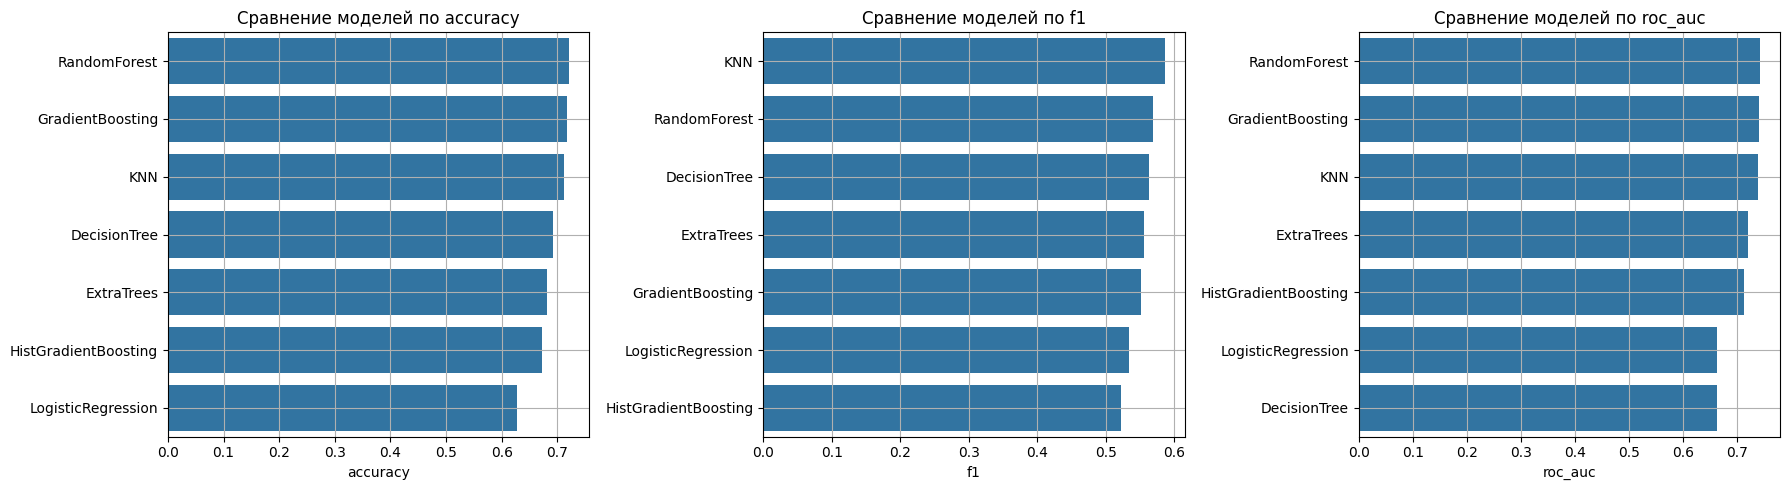

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_names = ["accuracy", "f1", "roc_auc"]

for i, metric in enumerate(metrics_names):

    sns.barplot(
        data=results_df.sort_values(
            metric,
            ascending=False
        ),
        x=metric,
        y="model",
        ax=axes[i]
    )

    axes[i].set_title(f"Сравнение моделей по {metric}")
    axes[i].set_ylabel("")
    axes[i].grid()

plt.tight_layout()
plt.show()

# Подбор гиперпараметров

После первичного сравнения моделей выполним подбор гиперпараметров для наиболее перспективных алгоритмов.

Для настройки выбраны KNN, RandomForestClassifier и GradientBoostingClassifier.

KNN показал лучший результат по F1 на первичном сравнении. RandomForest показал хорошее значение ROC-AUC и accuracy. GradientBoosting также показал стабильное качество и может лучше работать после настройки параметров.

В качестве основной метрики для подбора используется F1, так как в данной задаче важно сохранять баланс между precision и recall. Это особенно важно из-за умеренного дисбаланса классов: объектов с SI > 8 меньше, чем объектов с SI <= 8.

In [12]:
param_grids = {
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 11, 15],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"]
        }
    },

    "RandomForest": {
        "model": RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },

    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.03, 0.05, 0.1],
            "model__max_depth": [2, 3, 5]
        }
    }
}

In [13]:
selected_models = [
    "KNN",
    "RandomForest",
    "GradientBoosting"
]

grid_results = []

best_model = None
best_score = -np.inf
best_model_name = None

for name in selected_models:

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("model", param_grids[name]["model"])
    ])

    grid = GridSearchCV(
        pipe,
        param_grids[name]["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    grid_results.append({
        "model": name,
        "best_f1_cv": grid.best_score_,
        "best_params": grid.best_params_
    })

    if grid.best_score_ > best_score:
        best_score = grid.best_score_
        best_model = grid.best_estimator_
        best_model_name = name

grid_results_df = pd.DataFrame(grid_results)

grid_results_df = grid_results_df.sort_values(
    "best_f1_cv",
    ascending=False
)

grid_results_df

,model,best_f1_cv,best_params
1,RandomForest,0.599808,"{'model__max_depth': None, 'model__min_samples..."
0,KNN,0.575625,"{'model__metric': 'manhattan', 'model__n_neigh..."
2,GradientBoosting,0.563469,"{'model__learning_rate': 0.1, 'model__max_dept..."


По результатам GridSearchCV наилучшее значение F1 на кросс-валидации показала модель RandomForestClassifier.

На первичном сравнении лучший результат по F1 показывала KNN, однако после настройки гиперпараметров RandomForest оказался более устойчивым на кросс-валидации.

Лучшие параметры RandomForest включают 300 деревьев, отсутствие ограничения глубины и min_samples_leaf = 4. Это означает, что модель использует достаточно сложный ансамбль, но при этом ограничивает минимальный размер листа, что помогает снизить переобучение.

Однако окончательный выбор модели нельзя делать только по результатам кросс-валидации. Далее необходимо проверить качество подобранной модели на тестовой выборке и сравнить его с результатами модели до подбора.

In [14]:
best_model_name

'RandomForest'

# Оценка лучшей модели

После подбора гиперпараметров оценим лучшую модель на тестовой выборке.

Тестовая выборка не использовалась при обучении и подборе параметров, поэтому она позволяет проверить, насколько хорошо модель обобщает закономерности на новых данных.

В этой задаче особенно важно смотреть не только на accuracy, но и на precision, recall, F1 и ROC-AUC, так как положительный класс SI > 8 встречается реже.

In [15]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

best_metrics = classification_metrics(
    y_test,
    y_pred,
    y_proba
)

best_metrics

{'accuracy': 0.681592039800995,
 'precision': 0.5625,
 'recall': 0.5,
 'f1': 0.5294117647058824,
 'roc_auc': 0.7470391903531437}

# Сравнение качества до и после подбора

Сравним качество выбранной модели до и после подбора гиперпараметров.

Это нужно, чтобы понять, дал ли GridSearch реальное улучшение на тестовой выборке.

Если после подбора F1 и ROC-AUC выросли, значит настройка параметров была полезна. Если качество снизилось или изменилось незначительно, это тоже важный результат: он показывает, что модель с параметрами по умолчанию уже была достаточно устойчивой или что подобранные параметры переобучились на кросс-валидации.

In [16]:
before_tuning = results_df[
    results_df["model"] == best_model_name
].copy()

before_tuning["stage"] = "До подбора"

after_tuning = pd.DataFrame([best_metrics])
after_tuning["model"] = best_model_name
after_tuning["stage"] = "После подбора"

compare_tuning = pd.concat(
    [before_tuning, after_tuning],
    ignore_index=True
)

compare_tuning[
    ["stage", "model", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

,stage,model,accuracy,precision,recall,f1,roc_auc
0,До подбора,RandomForest,0.721393,0.637931,0.513889,0.569231,0.742840
1,После подбора,RandomForest,0.681592,0.562500,0.500000,0.529412,0.747039


Сравнение RandomForest до и после подбора гиперпараметров показало, что GridSearch не улучшил качество на тестовой выборке.

После подбора немного вырос ROC-AUC, однако снизились accuracy, precision, recall и F1. Так как основной метрикой для данной задачи является F1, подобранная версия RandomForest не выбирается в качестве финальной модели.

Это показывает, что лучший результат на кросс-валидации не всегда приводит к улучшению на тестовой выборке.

# Сравнение качества до и после подбора для KNN


In [17]:
knn_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

knn_grid = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

knn_grid.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'model__metric': ['euclidean', 'manhattan'], 'model__n_neighbors': [3, 5, ...], 'model__weights': ['uniform', 'distance']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,missing_values,nan


In [18]:
knn_grid.best_params_

{'model__metric': 'manhattan',
 'model__n_neighbors': 3,
 'model__weights': 'uniform'}

In [19]:
knn_tuned_model = knn_grid.best_estimator_

y_pred_knn_tuned = knn_tuned_model.predict(X_test)
y_proba_knn_tuned = knn_tuned_model.predict_proba(X_test)[:, 1]

knn_tuned_metrics = classification_metrics(
    y_test,
    y_pred_knn_tuned,
    y_proba_knn_tuned
)

knn_tuned_metrics

{'accuracy': 0.6716417910447762,
 'precision': 0.5405405405405406,
 'recall': 0.5555555555555556,
 'f1': 0.547945205479452,
 'roc_auc': 0.6968130921619293}

In [20]:
knn_before_tuning = results_df[
    results_df["model"] == "KNN"
].copy()

knn_before_tuning["stage"] = "До подбора"

knn_after_tuning = pd.DataFrame([knn_tuned_metrics])
knn_after_tuning["model"] = "KNN"
knn_after_tuning["stage"] = "После подбора"

knn_compare_tuning = pd.concat(
    [knn_before_tuning, knn_after_tuning],
    ignore_index=True
)

knn_compare_tuning[
    ["stage", "model", "accuracy", "precision", "recall", "f1", "roc_auc"]
]

,stage,model,accuracy,precision,recall,f1,roc_auc
0,До подбора,KNN,0.711443,0.602941,0.569444,0.585714,0.738426
1,После подбора,KNN,0.671642,0.540541,0.555556,0.547945,0.696813


Сравнение KNN до и после подбора гиперпараметров показало, что GridSearch не улучшил качество на тестовой выборке.

После подбора снизились accuracy, precision, F1 и ROC-AUC. Recall изменился незначительно, но общего улучшения качества не произошло.

Поэтому в качестве финальной модели не используется KNN после подбора. Лучшим вариантом остается KNN с параметрами по умолчанию, так как именно он показал максимальный F1 на тестовой выборке при первичном сравнении моделей.

In [21]:
final_model_name = "KNN"

final_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("variance", VarianceThreshold()),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

final_metrics = classification_metrics(
    y_test,
    y_pred,
    y_proba
)

final_metrics

{'accuracy': 0.7114427860696517,
 'precision': 0.6029411764705882,
 'recall': 0.5694444444444444,
 'f1': 0.5857142857142857,
 'roc_auc': 0.7384259259259259}

Так как подбор гиперпараметров не улучшил качество RandomForest и KNN на тестовой выборке, в качестве финальной модели была выбрана KNN с параметрами по умолчанию.

Эта модель показала лучший F1 на первичном сравнении моделей. Для данной задачи F1 является важной метрикой, так как классы умеренно несбалансированы, а положительный класс SI > 8 встречается реже.

Далее проанализируем финальную модель с помощью матрицы ошибок, ROC-кривой и permutation importance.

# Матрица ошибок

Матрица ошибок показывает, сколько объектов каждого класса модель классифицировала правильно и неправильно.

Класс 0 соответствует соединениям с SI <= 8.

Класс 1 соответствует соединениям с SI > 8.

В этой задаче особенно важно смотреть, сколько объектов класса SI > 8 модель смогла найти, так как именно такие соединения являются более перспективными по выбранному порогу.

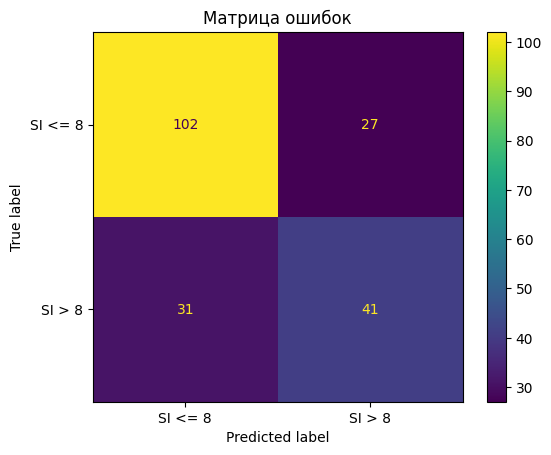

In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["SI <= 8", "SI > 8"]
)

disp.plot()

plt.title("Матрица ошибок")
plt.show()

In [23]:
tn, fp, fn, tp = cm.ravel()

print("True Negative:", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive:", tp)

True Negative: 102
False Positive: 27
False Negative: 31
True Positive: 41


Матрица ошибок показывает, что финальная модель лучше распознает класс SI <= 8, чем класс SI > 8.

Модель правильно классифицировала 102 объекта класса SI <= 8 и 41 объект класса SI > 8.

При этом было допущено 27 ложноположительных ошибок и 31 ложноотрицательная ошибка. Это означает, что модель иногда ошибочно относит соединения к классу SI > 8, а также пропускает часть соединений с высоким SI.

Для положительного класса SI > 8 модель нашла 41 объект из 72, то есть recall составляет около 0.57. Precision составляет около 0.60, что означает, что примерно 60% предсказаний класса SI > 8 оказались верными.

В целом модель работает лучше baseline, который вообще не находил объекты класса SI > 8, однако качество остается умеренным. Это подтверждает, что задача поиска соединений с SI > 8 является более сложной, чем классификация относительно медианы.

# ROC-кривая

ROC-кривая показывает способность модели разделять два класса при разных порогах классификации.

Класс 0 соответствует соединениям с SI <= 8.

Класс 1 соответствует соединениям с SI > 8.

Чем выше ROC-кривая расположена над диагональю случайного классификатора, тем лучше модель отличает перспективные соединения с SI > 8 от остальных.

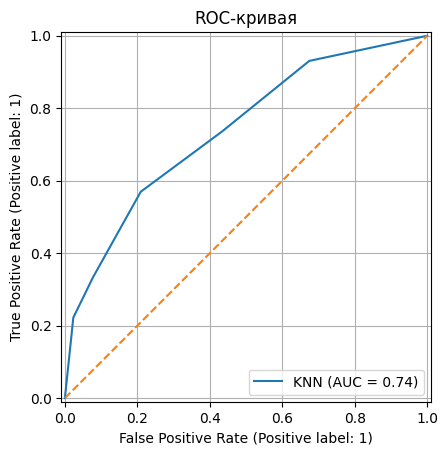

In [24]:
RocCurveDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    name=final_model_name
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.title("ROC-кривая")
plt.grid()
plt.show()

ROC-кривая показывает, что финальная модель KNN разделяет классы лучше случайного классификатора.

Значение ROC-AUC составляет около 0.74, что выше случайного уровня 0.5. Это означает, что модель использует полезную информацию из химических признаков.

При этом качество разделения нельзя назвать высоким. Модель показывает умеренный результат: она способна находить часть соединений с SI > 8, но допускает заметное количество ошибок.

Такой результат ожидаем, так как показатель SI является расчетной величиной от IC50 и CC50, а сами IC50 и CC50 были исключены из признаков для предотвращения утечки данных.

# Precision-Recall кривая

При несбалансированных классах ROC-AUC может завышать качество модели.

Precision-Recall кривая показывает реальный компромисс между полнотой и точностью при разных порогах классификации.

Площадь под PR-кривой (AP) — более строгая метрика для классов с дисбалансом.

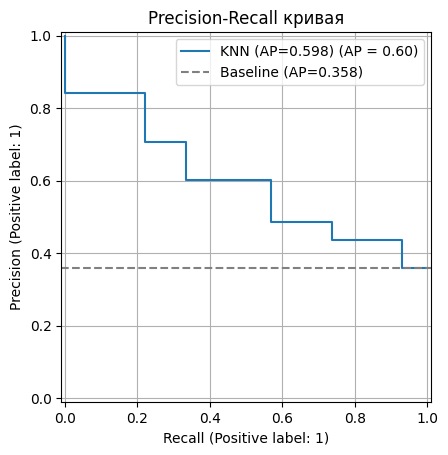

Average Precision (AP): 0.598


In [25]:
from sklearn.metrics import PrecisionRecallDisplay, average_precision_score

ap = average_precision_score(y_test, y_proba)

PrecisionRecallDisplay.from_estimator(
    final_model,
    X_test,
    y_test,
    name=f"{final_model_name} (AP={ap:.3f})"
)

# базовый уровень: доля положительного класса
baseline_ap = y_test.mean()
plt.axhline(baseline_ap, linestyle="--", color="gray", label=f"Baseline (AP={baseline_ap:.3f})")
plt.legend()
plt.title("Precision-Recall кривая")
plt.grid()
plt.show()

print(f"Average Precision (AP): {ap:.3f}")

Baseline на PR-кривой — горизонтальная линия на уровне доли положительного класса (около 0.36). Модель, которая работает лучше случайного, должна располагаться выше этой линии.

Значение Average Precision (AP) суммирует качество модели по всем порогам. Чем выше AP относительно baseline, тем лучше модель находит соединения с SI > 8.

PR-кривая дополняет ROC-AUC и даёт более реалистичную оценку в задачах с дисбалансом классов.

# Анализ важности признаков

Финальная модель KNN не имеет встроенного признака feature_importances_, поэтому для оценки важности признаков используется permutation importance.

Этот метод показывает, насколько ухудшается качество модели, если значения отдельного признака случайно перемешать.

Если после перемешивания признака качество сильно падает, значит этот признак был полезен для модели.

In [26]:
perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importances = pd.DataFrame({
    "feature": X.columns,
    "importance": perm_importance.importances_mean
})

importances = importances.sort_values(
    "importance",
    ascending=False
).head(15)

importances

,feature,importance
165,fr_ester,0.015742
89,EState_VSA4,0.012393
64,SMR_VSA3,0.010666
141,fr_NH1,0.010640
195,fr_piperzine,0.009057
25,BCUT2D_MRLOW,0.009051
130,fr_Ar_N,0.007834
140,fr_NH0,0.007021
155,fr_aryl_methyl,0.006921
2,MinAbsEStateIndex,0.006288


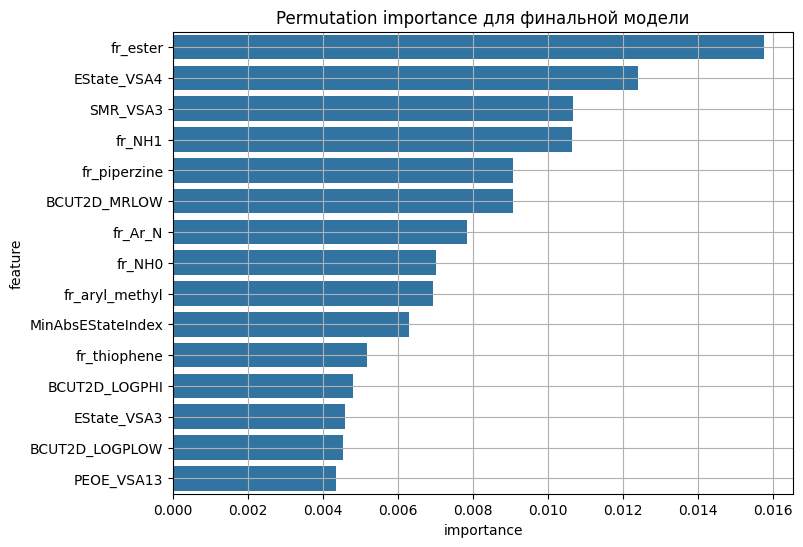

In [27]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=importances,
    x="importance",
    y="feature"
)

plt.title("Permutation importance для финальной модели")
plt.xlabel("importance")
plt.ylabel("feature")
plt.grid()

plt.show()

Permutation importance показал, что финальная модель KNN использует несколько признаков для классификации соединений по условию SI > 8.

Наиболее важными оказались признаки fr_ester, EState_VSA4, SMR_VSA3, fr_NH1, fr_piperzine, BCUT2D_MRLOW и fr_Ar_N.

Среди важных признаков есть как признаки отдельных химических фрагментов, так и более общие структурные и физико-химические дескрипторы. Это говорит о том, что модель использует не один отдельный показатель, а совокупность характеристик молекулы.

Значения permutation importance положительные, но небольшие. Это означает, что отдельные признаки вносят полезный вклад, но ни один из них не является явно доминирующим.

Такой результат согласуется с умеренным качеством модели: задача поиска соединений с SI > 8 является сложной, и доступные признаки позволяют выделить часть перспективных соединений, но не дают очень четкого разделения классов.

Важно отметить, что высокая важность признака не означает причинно-следственную связь. Она показывает только то, что данный признак оказался полезным для выбранной модели при решении задачи классификации.

Набор важных признаков отличается от задач классификации IC50 и CC50. Это ожидаемо, так как SI отражает не активность или токсичность по отдельности, а их соотношение.

# Выводы

В рамках задачи была построена модель бинарной классификации для определения того, превышает ли значение SI порог 8.

Показатель SI отражает соотношение цитотоксичности и противовирусной активности соединения. Чем выше SI, тем более перспективным может быть соединение с точки зрения баланса эффективности и безопасности.

В отличие от задач классификации относительно медианы, здесь использовался фиксированный порог `SI > 8`. Из-за этого классы получились умеренно несбалансированными: объектов с `SI <= 8` около 64%, а объектов с `SI > 8` около 36%.

Baseline-модель DummyClassifier показала accuracy около 0.64, но precision, recall и F1 были равны 0. Это связано с тем, что baseline всегда предсказывал самый частый класс `SI <= 8` и не находил ни одного потенциально перспективного соединения с `SI > 8`.

Поэтому в данной задаче accuracy не рассматривалась как главная метрика. Основной акцент был сделан на F1, recall, precision и ROC-AUC.

На первичном сравнении лучший результат по F1 показала модель KNN. Она получила accuracy около 0.71, precision около 0.60, recall около 0.57, F1 около 0.59 и ROC-AUC около 0.74. Это выше baseline, но качество нельзя назвать высоким.

Дополнительно был выполнен подбор гиперпараметров для KNN, RandomForestClassifier и GradientBoostingClassifier. По результатам кросс-валидации лучшей моделью выглядел RandomForestClassifier. Однако проверка на тестовой выборке показала, что после подбора его качество по F1 снизилось.

Также отдельно была проверена KNN после подбора гиперпараметров. Для неё качество на тестовой выборке также ухудшилось: снизились accuracy, precision, F1 и ROC-AUC.

Поэтому в качестве финальной модели была выбрана KNN с параметрами по умолчанию, так как именно она показала лучший F1 на тестовой выборке при первичном сравнении моделей.

Матрица ошибок показала, что модель правильно классифицировала 102 объекта класса `SI <= 8` и 41 объект класса `SI > 8`. При этом было допущено 27 ложноположительных и 31 ложноотрицательная ошибка.

Для положительного класса `SI > 8` модель нашла 41 объект из 72, то есть recall составил около 0.57. Precision составил около 0.60, то есть примерно 60% объектов, которые модель отнесла к классу `SI > 8`, действительно имели SI выше 8.

ROC-кривая показала значение ROC-AUC около 0.74. Это выше случайного уровня 0.5, значит модель действительно использует полезную информацию из химических признаков. Однако качество разделения остается умеренным.

Permutation importance показал, что для модели были полезны признаки fr_ester, EState_VSA4, SMR_VSA3, fr_NH1, fr_piperzine, BCUT2D_MRLOW и fr_Ar_N. Среди важных признаков есть как признаки отдельных химических фрагментов, так и более общие структурные и физико-химические дескрипторы.

Значения важности положительные, но небольшие. Это говорит о том, что модель не опирается на один доминирующий признак, а использует совокупность характеристик молекулы.

По сравнению с классификацией SI относительно медианы, задача `SI > 8` оказалась сложнее. Это связано с умеренным дисбалансом классов и с тем, что SI является расчетной величиной от IC50 и CC50, которые были исключены из признаков для предотвращения утечки данных.

Таким образом, задача поиска соединений с `SI > 8` решается лучше случайного угадывания, но качество остается умеренным. Финальная модель KNN может быть использована как базовый инструмент предварительного отбора перспективных соединений, однако для практического применения качество модели желательно улучшать за счет расширения данных, добавления новых химических дескрипторов и дополнительной настройки моделей.